## Load JAX, KDExpress, and matplotlib for plotting

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", 'cpu') # put 'gpu' here if you have one
import jax.numpy as jnp
import jax

import os,sys
parent_dir = os.getcwd() + '/../src/'
sys.path.append(parent_dir)
from KDExpress import fft_kde2d, silverman_bw2d, scott_bw2d
from KDExpress.hist import build_hist_edges

import matplotlib.pyplot as plt
from matplotlib.patches import Patch


import matplotlib.pyplot as plt
import matplotlib as mpl

custom_params = {
    # Spine settings - remove top/right, keep bottom/left
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    
    # Tick settings
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,        # Ensure bottom ticks are visible
    "ytick.left": True,          # Ensure left ticks are visible
    
    # Color settings
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.labelcolor": "black",
    
    # Grid settings - explicitly disable
    "axes.grid": False,
        
    # Light gray background settings
    "axes.facecolor": "0.95",    # Slightly lighter for axes background
    
    # TeX
    "text.usetex": True,
    "mathtext.fontset": "cm",
}

# First, restore default rcParams, then update
plt.rcParams.update(plt.rcParamsDefault)  # Restore defaults
plt.rcParams.update(custom_params)        # Apply your customizations

def scale_fonts_by_figsize(figsize, base_scale=1.0):
    """
    Automatically scale fonts based on figure size.
    
    Parameters
    ----------
    figsize : tuple
        Figure size in inches (width, height)
    base_scale : float
        Base scaling factor
    """
    fig_width = figsize[0]
    
    # Scale factor based on width (reference: 6.4 inches is matplotlib default)
    scale_factor = fig_width / 6.4 * base_scale
    
    font_params = {
        'font.size': 10 * scale_factor,
        'axes.titlesize': 11 * scale_factor,
        'axes.labelsize': 10 * scale_factor,
        'xtick.labelsize': 9 * scale_factor,
        'ytick.labelsize': 9 * scale_factor,
        'legend.fontsize': 8 * scale_factor,
        'figure.titlesize': 11 * scale_factor,
    }
    
    # Update only font parameters
    current_params = plt.rcParams.copy()
    current_params.update(font_params)
    plt.rcParams.update(current_params)

 ## Generate random weighted 2-D data 

/tmp/ipykernel_18409/1806379905.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = plt.cm.get_cmap('plasma')


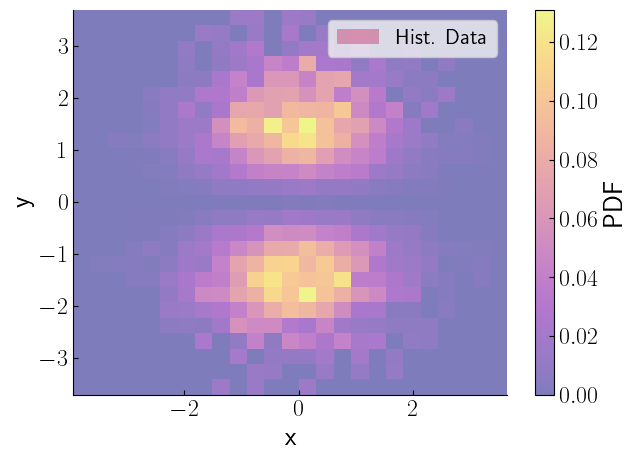

In [2]:
key = jax.random.PRNGKey(42)
data_2d = jax.random.normal(key, shape=(10_000, 2))
weights = (data_2d[:,0])**2

# Plot
scale_fonts_by_figsize(figsize=(7,5), base_scale=1.75)
plt.figure(figsize=(7,5))
h = plt.hist2d(
    data_2d[:, 1], data_2d[:, 0], 
    weights=weights, 
    bins=25, 
    density=True, 
    alpha=0.5,
    cmap='plasma' 
)
plt.ylabel("y")
plt.xlabel("x")
viridis = plt.cm.get_cmap('plasma')
proxy_color = viridis(0.5) 
proxy_artist = Patch(facecolor=proxy_color, alpha=0.5, label='Hist. Data')
plt.legend(handles=[proxy_artist])

plt.colorbar(h[3], label='PDF')

plt.show()

## Define the points where the PDF is evaluated and compute the bin edges around them and plot the corresponding histogram

Bin edges shape =  [(101,), (101,)]


/tmp/ipykernel_18409/3768275069.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = plt.cm.get_cmap('plasma')


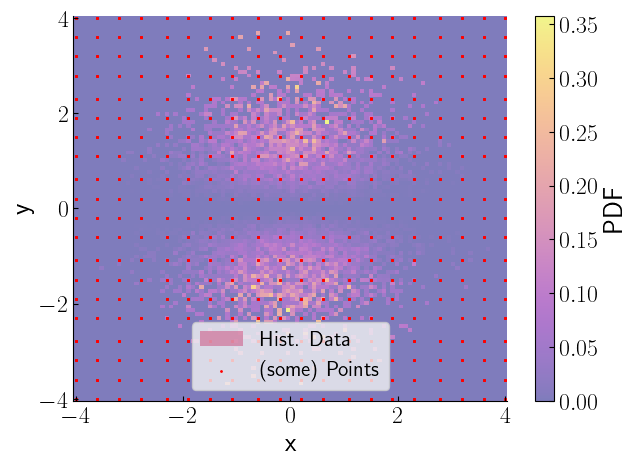

In [3]:
points_x = jnp.linspace(-4, 4, 100)
points_y = jnp.linspace(-4, 4, 100)
px, py = jnp.meshgrid(points_x, points_y, indexing='ij')
bin_edges = [build_hist_edges(points) for points in [points_x, points_y]]
print("Bin edges shape = ", [bin_edges[i].shape for i in range(2)])

plt.figure(figsize=(7,5))
h = plt.hist2d(
  data_2d[:, 1], data_2d[:, 0],  
  weights=weights, 
  bins=bin_edges, 
  density=True, 
  alpha=0.5,
  cmap='plasma'  
)
plt.ylabel("y")
plt.xlabel("x")
viridis = plt.cm.get_cmap('plasma')
proxy_color = viridis(0.5) 
ix = jnp.linspace(0,100,20).astype(int)
scatter_handle = plt.scatter(px[ix,:], py[:,ix], c='red', s=1 , label='(some) Points')
proxy_artist = Patch(facecolor=proxy_color, alpha=0.5, label='Hist. Data')
plt.legend(handles=[proxy_artist, scatter_handle])

plt.colorbar(h[3], label='PDF')

plt.show()

## The KDE is computed by convolving the previous "wavy" histogram with a Gaussian kernel. The convolution is (efficiently) performed using an FFT.

Estimated bandwidths Silverman (x, y) =  [0.19256654 0.19078095]
Estimated bandwidths Scott (x, y) =  [0.44800896 0.25126354]


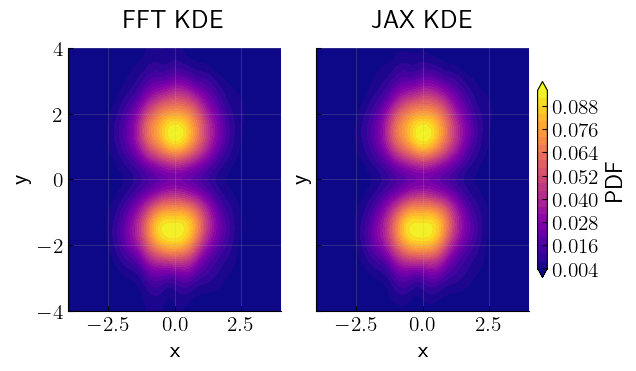

In [4]:
# Calculate optimal bandwidth using Silverman's rule for 2D data (or use custom value)
# Returns bandwidth for each dimension [bw_x, bw_y]
bw1 = silverman_bw2d(data_2d)  
print("Estimated bandwidths Silverman (x, y) = ", bw1)
bw2 = scott_bw2d(data_2d, weights)  
print("Estimated bandwidths Scott (x, y) = ", bw2)

# Compute 2D KDE using FFT-based method
# Note: Reusing bin_edges, though optional
pdf_est_fft = fft_kde2d(
  points_x, 
  points_y, 
  data_2d, 
  weights=weights, 
  bin_edges=bin_edges, 
  bw=bw2
)

# Compute JAX KDE 
def jax_scipy_kde2d(x_grid, y_grid, data, weights=None):
  kde = jax.scipy.stats.gaussian_kde(
    data.T,  
    weights=weights
  )
  X, Y = jnp.meshgrid(x_grid, y_grid, indexing='ij')
  positions = jnp.vstack([X.ravel(), Y.ravel()])
  density = kde(positions).reshape(X.shape)
  return density

pdf_est_jax = jax_scipy_kde2d(
  points_x, 
  points_y, 
  data_2d, 
  weights=weights, 
)

# Plot 
scale_fonts_by_figsize(figsize=(6.25, 3.6), base_scale=1.75)
fig, (ax1, ax2) = plt.subplots(
  1, 2, 
  figsize=(6.25, 3.6), 
  sharex=True, 
  sharey=True,
  constrained_layout=True
)

plot_kwargs = {
  'levels': 25, 
  'cmap': 'plasma',  
  'extend': 'both'  
}


im1 = ax1.contourf(
  points_x, 
  points_y, 
  pdf_est_fft, 
  **plot_kwargs
)
ax1.set_title('FFT KDE', pad=15)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(alpha=0.2)

# Plot JAX KDE results
im2 = ax2.contourf(
  points_x, 
  points_y, 
  pdf_est_jax, 
  **plot_kwargs
)
ax2.set_title("JAX KDE", pad=15)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(alpha=0.2)
fig.colorbar(
  im2, 
  ax=ax2, 
  label='PDF',
  fraction=0.046,
  pad=0.04
)
plt.savefig('kde_2d.pdf', bbox_inches='tight')
plt.show()

In [5]:
%timeit jax_scipy_kde2d(points_x, points_y, data_2d, weights=weights).block_until_ready()

436 ms ± 63.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [6]:
%timeit fft_kde2d(points_x, points_y, data_2d, weights=weights).block_until_ready()

1.66 ms ± 174 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
